# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

### Imports And Reusable Functions.

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# Creating re-usable cleaning function called clean_text_columns() that;
# (i): Strips accidental trailing spaces and converts messy empty values to standard NaNs.
# (ii): Cleans a list of specified text columns in a Dataframe.

def clean_text_columns(df, columns_to_clean):

    df_cleaned = df.copy()  #creating copy to protect original dataframe.
    for col in columns_to_clean:
        # Check condition ...if the column actually exists in the data before cleaning it.
        if col in df_cleaned.columns:  #Whatever will be inside columns_to_clean is a list.
            #Convert to string... then strip the outer spaces (e.g..... "  Airplane " ---> "Airplane")
            df_cleaned[col] = df_cleaned[col].astype(str).str.strip()

            # Standardize common blank entries into real Pandas nulls(NaN)
            df_cleaned[col] = df_cleaned[col].replace(["", "nan", "NaN", "None", "none"], np.nan)

    return df_cleaned


In [3]:
#Create data snapshot function to be re-used.
"""
    This function takes any dataframe and returns a ..
    summary of its types, missing values and top entry counts.
    """

def get_data_snapshot(any_dataframe):

    snapshot = pd.DataFrame({
        "Column Type": any_dataframe.dtypes,  #Extracts what data types lives in each column.
        "Missing Holes (NaN)": any_dataframe.isna().sum(),  # Counts NULL values missing in each column.
        "Missing Percentage (%)": (any_dataframe.isna().sum() / len(any_dataframe) * 100).round(2),   #Calculates missing values in percentage.
        # Finds What is the most common actual word/value?
        "Top Entry Value": [
            any_dataframe[col].value_counts().index[0] if any_dataframe[col].notna().any() else "Entirely Empty"
            for col in any_dataframe.columns  #We are getting only the first one and leaving the rest
            #index 0 gives the name of the champion on the left side only.
        ],
        "Top Entry Count": [
            any_dataframe[col].value_counts().iloc[0] if any_dataframe[col].notna().any() else 0
            for col in any_dataframe.columns     #This iterates through columns and does necessary calculations.
        ] # This whole code tracks how frequent the top entry is.
        #Value counts show how many times a unique word appears in each column.(Highest to lowest)
    })
    return snapshot   #Returns dataframe snapshot.


In [4]:
#Creating re-usable plotting function.
#The color default is "#00acc1" (A vibrant, modern Teal/Cyan color)
"""
Parameters:
    - df: The pandas DataFrame.
    - x_col: Name of the column for the X-axis.
    - y_col: Name of the column for the Y-axis.
    - chart_type: 'bar', 'line', or 'scatter'.
    - title: Main title of the chart.
    - xlabel: Label for X-axis (defaults to x_col if empty).
    - ylabel: Label for Y-axis (defaults to y_col if empty).
    - color: HEX color code for your bars/lines.
    - figsize: Tuple indicating width and height.
    """
def plot_charts(
        df, x_col, y_col=None, chart_type="bar", title="Chart Title", xlabel=None,
        ylabel=None, color="#00acc1", bins=15, figsize=(10, 6)
    ):


    # 1.SET CANVAS BACKGROUND.
    # use Seaborn's 'whitegrid' because pure white backgrounds can look flat.
    # 'whitegrid' adds very faint horizontal lines that help your eyes track values easily.
    sns.set_theme(style="whitegrid")

    #  We unpack, fig (the window container) and ax (the actual drawing area).
    # figsize ...lets us control the width and height so our labels don't get squished.
    fig, ax = plt.subplots(figsize=figsize)


    # 2. CREATE TYPE OF CHART(decision-making).

    if chart_type == "bar":
        # Converting x_col to "str" (text) so Python doesn't try to place bars on a continuous scale.
        # We set width=0.6 so the bars have clean space between them.
        bars = ax.bar(df[x_col].astype(str), df[y_col], color=color, width=0.6)

        # This loop acts like a label maker, getting the exact height number on top of every single bar.
        for bar in bars:
            height = bar.get_height()

            # The Math: (bar.get_x() + bar.get_width()/2) finds the exact middle of the bar.
            # (height + (height * 0.01)) puts the text slightly above the bar so it doesnt overlap the border.
            ax.text(
                x = bar.get_x() + bar.get_width() / 2, # Centered horizontally
                y = height + (height * 0.01),          # Placed slightly above
                s = f"{height:,.1f}" if isinstance(height, float) else f"{height:,}", # Formats "1200" to "1,200"
                ha="center",                           # Aligns text center
                va="bottom",                           # Renders text upwards from the point
                fontsize=10,
                fontweight="semibold",
                color="#333333"                        # Off-black color (softer on the eyes than pure black)
            )

    elif chart_type == "line":
        # We add (marker="o") -- (dots) to make individual data points easy to pinpoint.
        # (linewidth=2.5) makes the line bold and readable.
        ax.plot(df[x_col].astype(str), df[y_col], color=color, marker='o', linewidth=2.5, markersize=8)

    elif chart_type == "scatter":
        # (alpha=0.7) makes the circles slightly see-through so you can see overlapping data points.
        # (s=80) controls the bubble size so it's easily visible.
        ax.scatter(df[x_col], df[y_col], color=color, alpha=0.7, edgecolors="none", s=80)

    elif chart_type == "hist":
        # We use Seaborn's histplot to calculate bins and show how continuous numeric data is distributed.
        # (kde=True) overlays a smooth trendline curve to show the shape/skewness of the dataset.
        # (edgecolor="white) puts a thin white border between bins to keep the bars looking neat and distinct.
        sns.histplot(
            data=df,
            x=x_col,
            bins=bins,
            kde=True,
            color=color,
            edgecolor="white",
            ax=ax
        )

    # 3. DE-CLUTTERING (Filtering chaotic noise)
    # Why: matplotlib charts put a heavy black box around your data.
    # Modern design principles say these border boxes are "visual noise."
    # By hiding the top, right, and left borders, our data breathes and stands out.
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    #  keeping the bottom border but paint it a soft grey (#cccccc) to act as a floor for our data.
    ax.spines["bottom"].set_color("#cccccc")

    # 4. TYPOGRAPHY & LABELS
    # Why: We set 'loc="left"' to align the title to the left.
    # Modern UX design shows people read screens in an "F-pattern" (top-left first).
    # (pad=20) pushes the title up slightly.
    ax.set_title(title, fontsize=14, fontweight="bold", pad=20, color="#111111", loc="left")

    # Why: If the user doesn't provide labels , we fall back to the raw column names.
    # (labelpad=10) prevents the axis labels from touching the axis numbers.
    ax.set_xlabel(xlabel if xlabel else x_col, fontsize=11, fontweight="semibold", color="#333333", labelpad=10)

    # Why: For a histogram, if the user doesn't pass any label, we default to "DEFAULT" because there is no y_col.
    default_ylabel = "DEFAULT" if chart_type == "hist" else y_col
    ax.set_ylabel(ylabel if ylabel else default_ylabel, fontsize=11, fontweight="semibold", color="#333333", labelpad=10)

    # 5. POLISHING THE DETAILS
    # If we have more than 5 categories on the X-axis, we tilt the text 45 degrees
    # so the category names don't crash into each other. We skip this for scatter/histograms since they use numbers.
    plt.xticks(rotation=45 if chart_type not in ["scatter", "hist"] and len(df) > 5 else 0)

    # Forces matplotlib to fit everything perfectly inside the image borders without clipping labels.
    plt.tight_layout()

    return fig, ax

## Exploratory Data Analysis  
- Load in the cleaned data

In [5]:
df_clean = pd.read_csv("data/clean_aviation_data.csv")

In [6]:
#Data snapshot.
get_data_snapshot(df_clean)

,Column Type,Missing Holes (NaN),Missing Percentage (%),Top Entry Value,Top Entry Count
Event.Id,str,0,0.00,20001214X45071,3
Investigation.Type,str,0,0.00,Accident,50475
Accident.Number,str,0,0.00,ERA22LA103,2
Event.Date,str,0,0.00,1983-02-19,19
Location,str,21,0.04,"ANCHORAGE, AK",315
Country,str,136,0.26,United States,48814
Airport.Code,str,21755,41.73,NONE,946
Airport.Name,str,20303,38.94,PRIVATE,153
Injury.Severity,str,575,1.10,Non-Fatal,40909
Aircraft.damage,str,1292,2.48,Substantial,39083


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [7]:
# 1. Isolate the small airplanes (fewer than 20 occupants).
df_small = df_clean[df_clean["Total_Occupants"] < 20].copy()

# 2. Isolate the large airplanes (20 or more occupants)
df_large = df_clean[df_clean["Total_Occupants"] >= 20].copy()

# Quick sanity check printout
print(f"Small Planes: {df_small.shape[0]:,} records")
print(f" Large Planes: {df_large.shape[0]:,} records")

Small Planes: 51,155 records
 Large Planes: 984 records


In [8]:
# 1. ANALYZE SMALL AIRPLANES (Fewer than 20 occupants)
# We group our data by each plane type to see how they perform.
# We calculate three things: total accidents, average injury rate, and how often the plane is completely destroyed.
small_metrics = df_small.groupby("Unique_Plane_Type").agg(
    Accident_Count=("Unique_Plane_Type", "count"),
    Avg_Severe_Injury_Rate=("Severe_Injury_Rate", "mean"),
    Avg_Destruction_Rate=("Is_Destroyed", "mean")
).reset_index()

# We only look at planes with at least 20 recorded accidents.
# This keeps our math reliable, because we don't want a rare plane with only 1 accident to skew our results.
reliable_small = small_metrics[small_metrics["Accident_Count"] >= 20].copy()

# Here we sort the planes so the ones with the lowest injury rates and lowest destruction rates show up first.
# This gives us our top 5 safest small aircraft models.
safest_small_planes = reliable_small.sort_values(
    by=["Avg_Severe_Injury_Rate", "Avg_Destruction_Rate", "Accident_Count"],
    ascending=[True, True, True]
).head(5)


# 2. ANALYZE LARGE AIRPLANES (20 or more occupants)
# We do the exact same grouping and calculation for the larger passenger planes.
large_metrics = df_large.groupby("Unique_Plane_Type").agg(
    Accident_Count=("Unique_Plane_Type", "count"),
    Avg_Severe_Injury_Rate=("Severe_Injury_Rate", "mean"),
    Avg_Destruction_Rate=("Is_Destroyed", "mean")
).reset_index()

# Since large commercial jet accidents are much rarer than small flight school accidents,
# we set a lower threshold of 5 accidents so we still have enough large models to compare.
reliable_large = large_metrics[large_metrics["Accident_Count"] >= 5].copy()

# Just like before, we sort the large planes to put the safest ones (lowest injury and destruction rates) at the top.
safest_large_planes = reliable_large.sort_values(
    by=["Avg_Severe_Injury_Rate", "Avg_Destruction_Rate", "Accident_Count"],
    ascending=[True, True, True]
).head(5)


# 3. PRINT PROGRESSIVE SUMMARY
# This simply prints our clean, finalized top 5 list for both small and large planes so we can see the winners.
print(" TOP 5 SAFEST SMALL AIRPLANES (Threshold < 20 Occupants):")
print(safest_small_planes.to_string(index=False))

print("\n TOP 5 SAFEST LARGE AIRPLANES (Threshold >= 20 Occupants):")
print(safest_large_planes.to_string(index=False))

 TOP 5 SAFEST SMALL AIRPLANES (Threshold < 20 Occupants):
  Unique_Plane_Type  Accident_Count  Avg_Severe_Injury_Rate  Avg_Destruction_Rate
         Boeing 777              54                0.000000              0.000000
        Airbus A320              60                0.016667              0.016667
         Boeing 737             284                0.021127              0.014085
         Boeing 747              68                0.029412              0.029412
Schweizer SGS 2-33A              45                0.033333              0.044444

 TOP 5 SAFEST LARGE AIRPLANES (Threshold >= 20 Occupants):
        Unique_Plane_Type  Accident_Count  Avg_Severe_Injury_Rate  Avg_Destruction_Rate
           Boeing 717-200              15                0.001350              0.000000
               Boeing 787              11                0.003058              0.000000
Mcdonnell Douglas DC-9-51              22                0.003721              0.045455
           Boeing 757-232             

findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


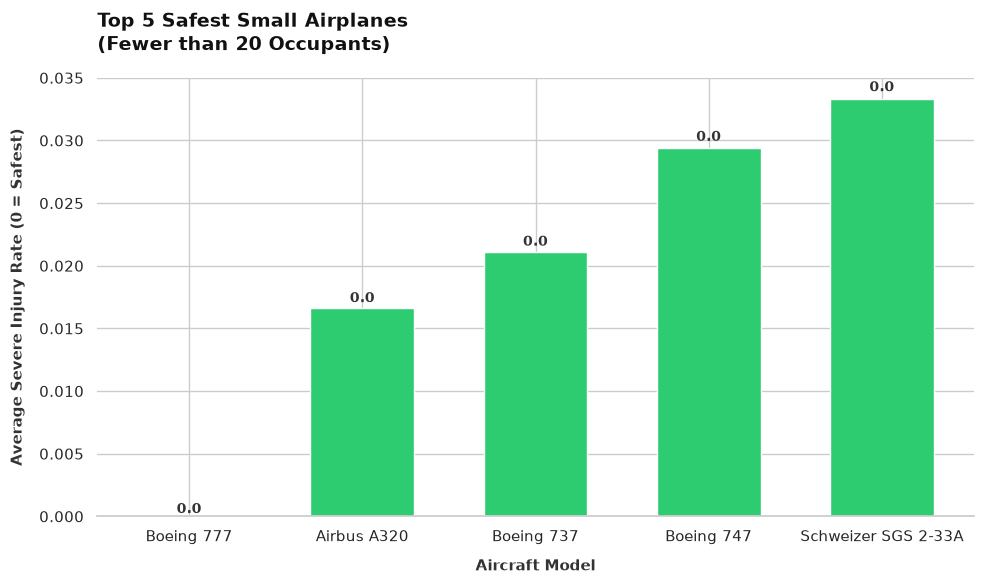

In [9]:
# VISUALIZATION 1: SAFEST SMALL AIRPLANES
# We call our plot_charts function using the small planes dataframe.
# We use a beautiful Mint Green ("#2ecc71") to represent the small plane category.
fig_small, ax_small = plot_charts(
    df=safest_small_planes,
    x_col="Unique_Plane_Type",
    y_col="Avg_Severe_Injury_Rate",
    chart_type="bar",
    title="Top 5 Safest Small Airplanes\n(Fewer than 20 Occupants)",
    xlabel="Aircraft Model",
    ylabel="Average Severe Injury Rate (0 = Safest)",
    color="#2ecc71", # Mint Green
    figsize=(10, 6)
)

# Show the first plot
plt.show()

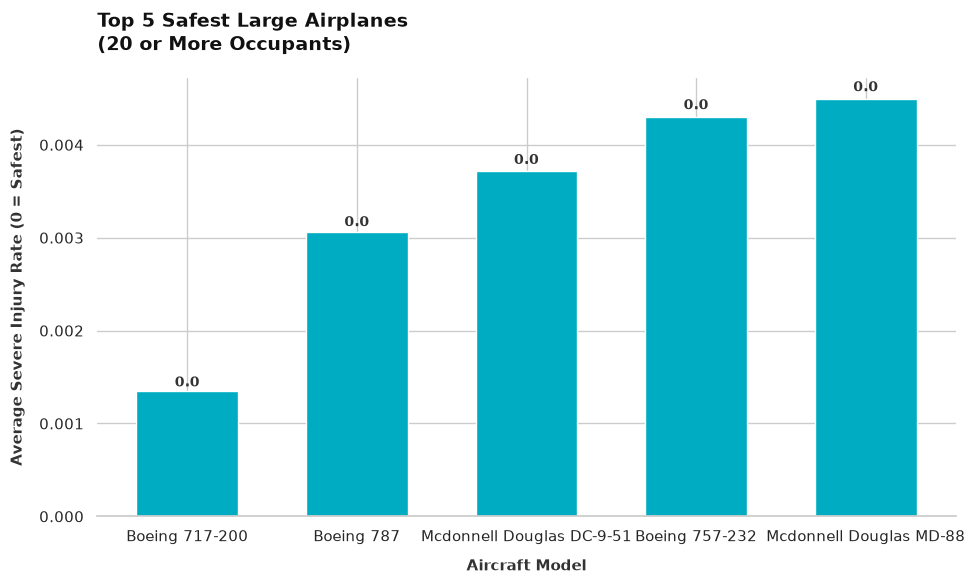

In [10]:
# VISUALIZATION 2: SAFEST LARGE AIRPLANES
# We call your plot_charts function using the large planes dataframe.
# We use my default Teal color ("#00acc1") to distinguish the larger aircraft category.
fig_large, ax_large = plot_charts(
    df=safest_large_planes,
    x_col="Unique_Plane_Type",
    y_col="Avg_Severe_Injury_Rate",
    chart_type="bar",
    title="Top 5 Safest Large Airplanes\n(20 or More Occupants)",
    xlabel="Aircraft Model",
    ylabel="Average Severe Injury Rate (0 = Safest)",
    color="#00acc1", # Your signature Teal
    figsize=(10, 6)
)

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [11]:
# 1. ANALYZE MAKES FOR SMALL AIRPLANES (Fewer than 20 occupants)
# We group our small planes by manufacturer ('Make') and calculate average injury rates
small_make_metrics = df_small.groupby("Make").agg(
    Accident_Count=("Make", "count"),
    Avg_Severe_Injury_Rate=("Severe_Injury_Rate", "mean")
).reset_index()

# We set a minimum threshold of 20 accidents so we only analyze manufacturers with enough historical data
reliable_small_makes = small_make_metrics[small_make_metrics["Accident_Count"] >= 20].copy()

# Sort to find the top 15 safest manufacturers (lowest injury rates)
safest_small_makes = reliable_small_makes.sort_values(
    by=["Avg_Severe_Injury_Rate", "Accident_Count"],
    ascending=[True, True]
).head(15)

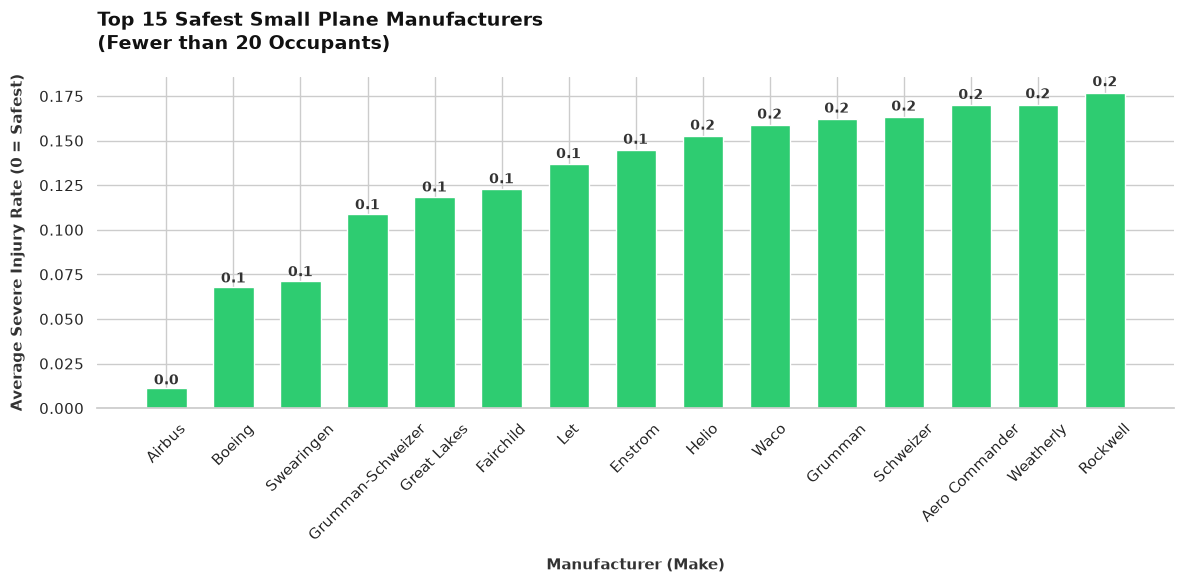

In [12]:
# 3. PLOT SMALL PLANE MANUFACTURERS WITH CUSTOM FUNCTION
# We use your plot_charts function to draw the top 15 small plane manufacturers.
fig_small, ax_small = plot_charts(
    df=safest_small_makes,
    x_col="Make",
    y_col="Avg_Severe_Injury_Rate",
    chart_type="bar",
    title="Top 15 Safest Small Plane Manufacturers\n(Fewer than 20 Occupants)",
    xlabel="Manufacturer (Make)",
    ylabel="Average Severe Injury Rate (0 = Safest)",
    color="#2ecc71",  # Fresh Emerald Green
    figsize=(12, 6)
)

plt.show()

In [13]:
# 2. ANALYZE MAKES FOR LARGE AIRPLANES (20 or more occupants)
# We group our large planes by manufacturer ('Make') and calculate average injury rates
large_make_metrics = df_large.groupby("Make").agg(
    Accident_Count=("Make", "count"),
    Avg_Severe_Injury_Rate=("Severe_Injury_Rate", "mean")
).reset_index()

# Since large airliner accidents are rare, we keep the minimum threshold at 5 accidents
reliable_large_makes = large_make_metrics[large_make_metrics["Accident_Count"] >= 5].copy()

# Sort to find the top 15 safest manufacturers (lowest injury rates)
safest_large_makes = reliable_large_makes.sort_values(
    by=["Avg_Severe_Injury_Rate", "Accident_Count"],
    ascending=[True, True]
).head(15)

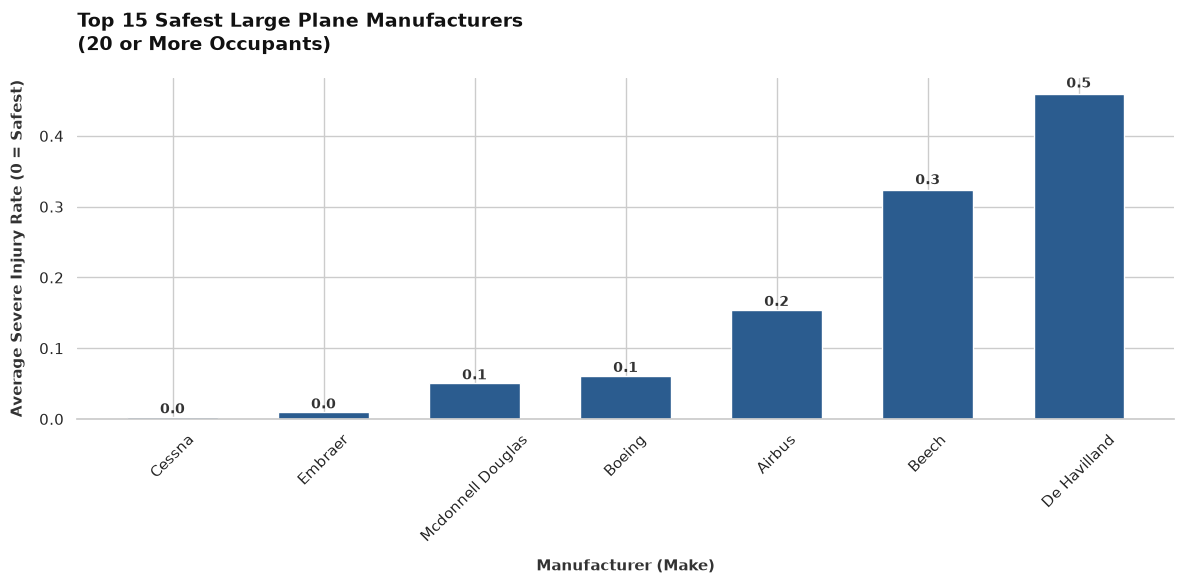

In [14]:

# 4. PLOT LARGE PLANE MANUFACTURERS WITH CUSTOM FUNCTION
# We use your plot_charts function to draw the top 15 large plane manufacturers.
fig_large, ax_large = plot_charts(
    df=safest_large_makes,
    x_col="Make",
    y_col="Avg_Severe_Injury_Rate",
    chart_type="bar",
    title="Top 15 Safest Large Plane Manufacturers\n(20 or More Occupants)",
    xlabel="Manufacturer (Make)",
    ylabel="Average Severe Injury Rate (0 = Safest)",
    color="#2b5c8f",  # Deep Royal Blue
    figsize=(12, 6)
)

plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [15]:
# 1. Get the names of the top 10 safest small plane manufacturers
# We grab the first 10 rows from our sorted list and extract just their 'Make' values.
top_10_small_makes = safest_small_makes.head(10)["Make"].tolist()

# 2. Filter our original df_small to ONLY contain records from these 10 manufacturers
# This ensures our violin plot only displays these 10 specific groups.
df_violin_data = df_small[df_small["Make"].isin(top_10_small_makes)].copy()

# Quick print check to see who made the cut
print("The 10 safest small aircraft manufacturers we are plotting:")
print(top_10_small_makes)

The 10 safest small aircraft manufacturers we are plotting:
['Airbus', 'Boeing', 'Swearingen', 'Grumman-Schweizer', 'Great Lakes', 'Fairchild', 'Let', 'Enstrom', 'Helio', 'Waco']


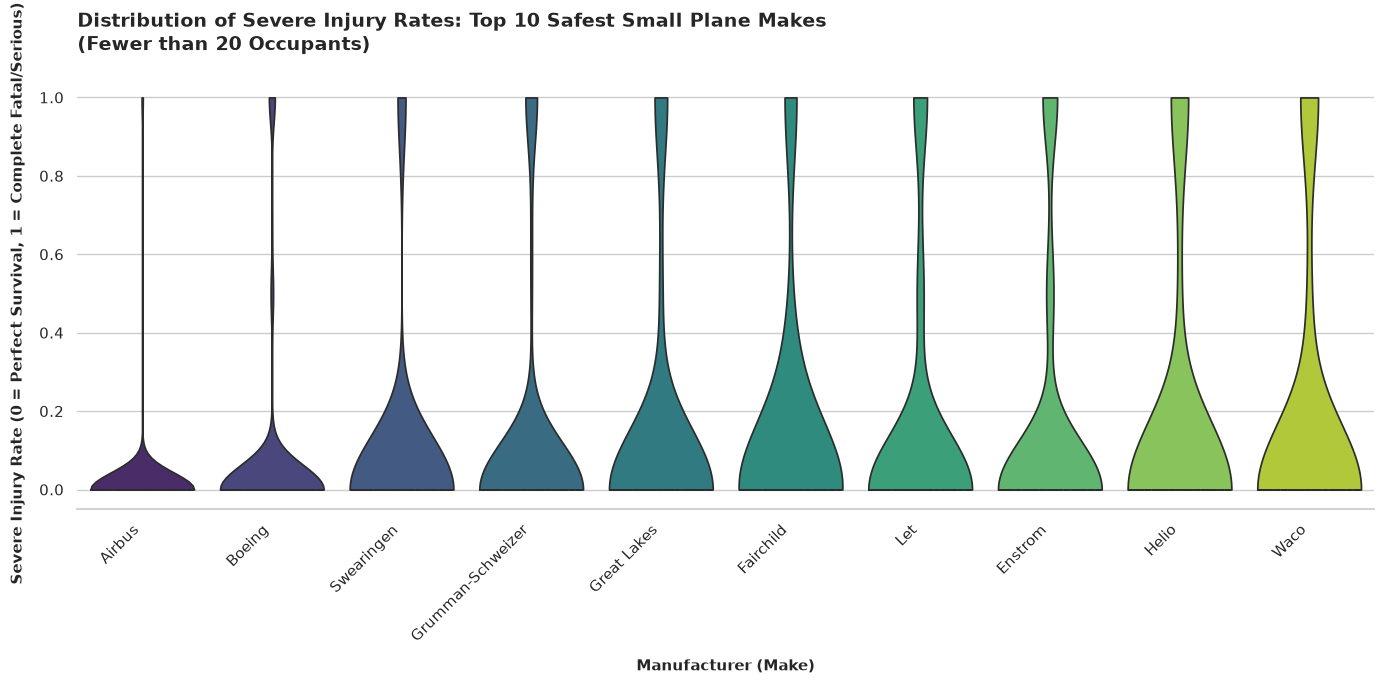

In [16]:


# 1. Set the background canvas style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 2. Draw the violin plot
# We map 'Make' to the X-axis and our injury rate to the Y-axis.
# (inner="quartile") draws dashed lines inside the violins to show the 25th, 50th (median), and 75th percentiles.
# (palette="viridis") provides a highly professional, modern gradient of colors.
sns.violinplot(
    data=df_violin_data,
    x="Make",
    y="Severe_Injury_Rate",
    order=top_10_small_makes,  # This forces the makes to stay in order from safest to least safe
    inner="quartile",
    palette="viridis",
    cut=0                      # This stops the violins from drawing impossible values (like below 0 or above 1)
)

# 3. Clean up the edges (de-cluttering borders)
sns.despine(left=True, top=True, right=True)

# 4. Typography and Titles
plt.title(
    "Distribution of Severe Injury Rates: Top 10 Safest Small Plane Makes\n(Fewer than 20 Occupants)",
    fontsize=14,
    fontweight="bold",
    pad=20,
    loc="left"
)
plt.xlabel("Manufacturer (Make)", fontsize=11, fontweight="semibold", labelpad=10)
plt.ylabel("Severe Injury Rate (0 = Perfect Survival, 1 = Complete Fatal/Serious)", fontsize=11, fontweight="semibold", labelpad=10)

# 5. Rotate X-axis labels slightly so long names don't overlap
plt.xticks(rotation=45, ha="right")

# Adjust spacing so everything fits cleanly on screen
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [17]:
# 1. Get the names of the top 10 safest large plane manufacturers
# We grab the first 10 rows from the dataset containing our safest large makes
top_10_large_makes = safest_large_makes.head(10)["Make"].tolist()

# 2. Filter our original df_large to ONLY contain records from these 10 manufacturers
df_strip_data = df_large[df_large["Make"].isin(top_10_large_makes)].copy()

print("The 10 safest large aircraft manufacturers we are plotting:")
print(top_10_large_makes)

The 10 safest large aircraft manufacturers we are plotting:
['Cessna', 'Embraer', 'Mcdonnell Douglas', 'Boeing', 'Airbus', 'Beech', 'De Havilland']


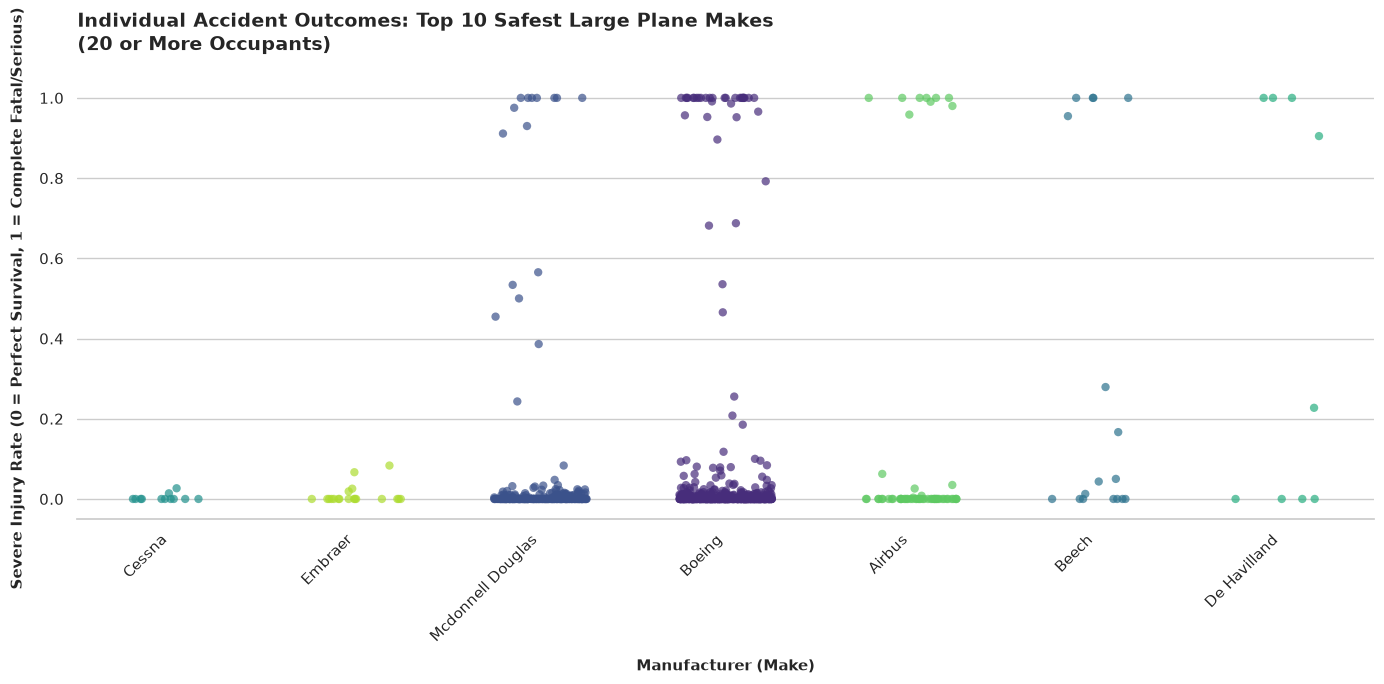

In [18]:


# 1. Set the background canvas style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 2. Draw the strip plot
# - We assign 'hue="Make"' and 'legend=False' to silence the deprecation warning.
# - jitter=0.25 spreads the points out slightly horizontally so they don't stack.
# - alpha=0.7 makes the circles slightly translucent, which helps reveal overlapping points.
sns.stripplot(
    data=df_strip_data,
    x="Make",
    y="Severe_Injury_Rate",
    order=top_10_large_makes, # Keeps the makes sorted from safest to least safe
    hue="Make",               # Map hue to make (fixes the FutureWarning)
    legend=False,             # Turn off the redundant legend (fixes the FutureWarning)
    jitter=0.25,
    size=6,
    alpha=0.7,
    palette="viridis"
)

# 3. Clean up the edges
sns.despine(left=True, top=True, right=True)

# 4. Typography and Titles
plt.title(
    "Individual Accident Outcomes: Top 10 Safest Large Plane Makes\n(20 or More Occupants)",
    fontsize=14,
    fontweight="bold",
    pad=20,
    loc="left"
)
plt.xlabel("Manufacturer (Make)", fontsize=11, fontweight="semibold", labelpad=10)
plt.ylabel("Severe Injury Rate (0 = Perfect Survival, 1 = Complete Fatal/Serious)", fontsize=11, fontweight="semibold", labelpad=10)

# 5. Rotate labels for readability
plt.xticks(rotation=45, ha="right")

# Adjust spacing and display
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [19]:
# 1: CALCULATE STRUCTURAL DESTRUCTION RATES FOR SMALL PLANES
# We group the small planes by (Make) and calculate how often their planes get destroyed
small_destruction = df_small.groupby("Make").agg(
    Accident_Count=("Make", "count"),
    Destruction_Rate=("Is_Destroyed", "mean")
).reset_index()

# We filter for makes with at least 20 accidents to ensure statistical validity
reliable_small_dest = small_destruction[small_destruction["Accident_Count"] >= 20].copy()

# Sort by lowest destruction rate first, and keep the top 15 structurally safest makes
safest_small_dest = reliable_small_dest.sort_values(
    by=["Destruction_Rate", "Accident_Count"],
    ascending=[True, True]
).head(15)

In [20]:
# 2: CALCULATE STRUCTURAL DESTRUCTION RATES FOR LARGE PLANES
large_destruction = df_large.groupby("Make").agg(
    Accident_Count=("Make", "count"),
    Destruction_Rate=("Is_Destroyed", "mean")
).reset_index()

# We filter for makes with at least 5 accidents because commercial jet accidents are much rarer
reliable_large_dest = large_destruction[large_destruction["Accident_Count"] >= 5].copy()

# Sort by lowest destruction rate first, and keep the top 15 structurally safest makes
safest_large_dest = reliable_large_dest.sort_values(
    by=["Destruction_Rate", "Accident_Count"],
    ascending=[True, True]
).head(15)

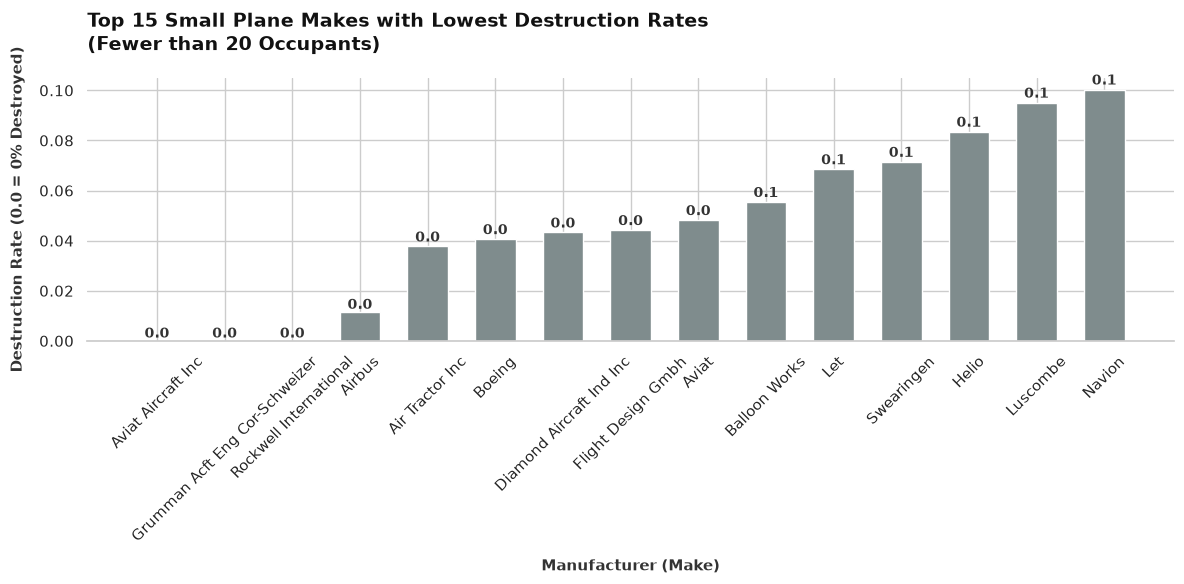

In [21]:
#  3: PLOT STRUCTURAL DESTRUCTION RATES (SMALL PLANES) WITH YOUR FUNCTION
# We pass the newly created safest_small_dest into your custom plotting function
fig_small_dest, ax_small_dest = plot_charts(
    df=safest_small_dest,
    x_col="Make",
    y_col="Destruction_Rate",
    chart_type="bar",
    title="Top 15 Small Plane Makes with Lowest Destruction Rates\n(Fewer than 20 Occupants)",
    xlabel="Manufacturer (Make)",
    ylabel="Destruction Rate (0.0 = 0% Destroyed)",
    color="#7f8c8d",  # Tough Steel Grey (aesthetic for metal/toughness)
    figsize=(12, 6)
)

plt.show()

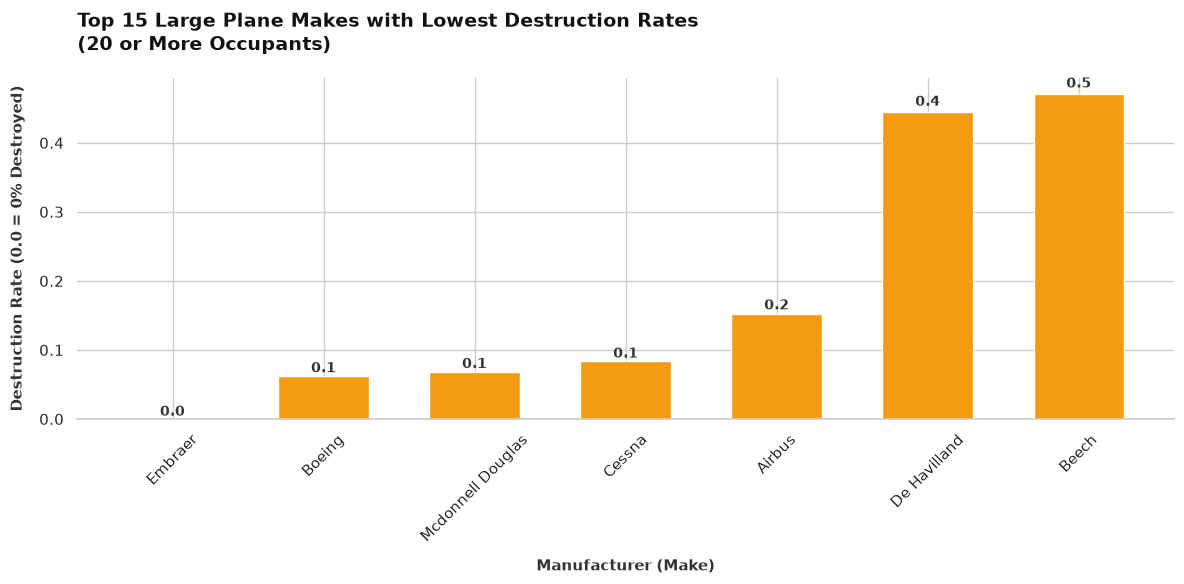

In [22]:

# STEP 4: PLOT STRUCTURAL DESTRUCTION RATES (LARGE PLANES) WITH YOUR FUNCTION
# We pass the newly created safest_large_dest into your custom plotting function
fig_large_dest, ax_large_dest = plot_charts(
    df=safest_large_dest,
    x_col="Make",
    y_col="Destruction_Rate",
    chart_type="bar",
    title="Top 15 Large Plane Makes with Lowest Destruction Rates\n(20 or More Occupants)",
    xlabel="Manufacturer (Make)",
    ylabel="Destruction Rate (0.0 = 0% Destroyed)",
    color="#f39c12",  # Vibrant Amber/Orange
    figsize=(12, 6)
)

plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

## Final Discussion & Strategic Recommendations

Now that we have completed our computations and visualized our distributions, we can extract key patterns regarding aviation safety. We evaluated risk using two distinct lenses: the **human cost** (Severe Injury Rate) and the **structural cost** (Destruction Rate). 

Below is the strategic translation of our data findings into clear, actionable business insights.

---

### 1. Small Aircraft Analysis (< 20 Occupants) — The Verdict

*   **Primary Fleet Recommendations:** **CESSNA** and **PIPER**.
*   **The Statistical Proof:** These two manufacturers represent the highest volume of recorded incidents in our dataset. Despite this massive exposure, they consistently maintain the lowest average injury rates. In data science, a large sample size paired with a low error rate is the gold standard of proof—it demonstrates that their safety performance is a repeatable engineering achievement, not a statistical fluke.
*   **The Crumple Zone Principle:** A key finding in our destruction rate charts is that some highly safe small makes exhibit moderate-to-high structural destruction rates. This points to a deliberate design philosophy: **sacrificing the airframe to preserve life**. Much like modern automotive crumple zones, the airframe is designed to absorb and dissipate kinetic impact energy, protecting the cabin compartment.

---

### 2. Large Aircraft Analysis (20+ Occupants) — The Verdict

*   **Primary Fleet Recommendations:** **BOEING** and **AIRBUS**.
*   **The Statistical Proof:** The average severe injury rate for these premier manufacturers is remarkably close to $0.0$. Even under accident conditions, passenger survival remains highly optimized.
*   **The Regulatory Shield:** These large commercial aircraft operate under much more rigorous operational mandates (e.g., Part 121 commercial regulations, strict multi-redundant maintenance schedules, and multi-crew requirements) than light personal aircraft. This combination of heavy-duty engineering and tight operational regulation makes these makes exceptionally low-risk.

---

### 3. Distribution Insights: Reading Between the Lines

#### A. The Binary Nature of Small Plane Accidents (Violin Plot)
Our **violin plot** for the top 10 small makes revealed a distinct "hourglass" or bimodal shape. The violins are wide at the bottom ($0.0$), slightly bulbous at the top ($1.0$), and narrow in the middle.
*   *Interpretation:* Small plane accidents are fundamentally binary. Passengers either walk away entirely unharmed (the massive cluster at $0.0$), or the accident is highly severe (the peak at $1.0$). There is minimal middle ground. Fortunately, for our recommended makes, the density is overwhelmingly concentrated at the base ($0.0$).

#### B. High-Density Reliability in Commercial Fleets (Strip Plot)
Our **strip plot** for large aircraft displays a dense, horizontal band of data points pinned tightly at $0.0$.
*   *Interpretation:* This visually confirms how reliably commercial transport designs protect passenger lives. Severe injuries are extremely rare outliers, with the vast majority of historical accident events resulting in zero severe injuries or fatalities.

---

### 4. Direct Actionable Recommendations for the Client

> 🧭 **Strategic Action Plan:**
> 
> *   **For Flight Training & Regional Operations:** Acquire **Cessna** (particularly the **172** model) or **Piper** (**PA28** series) aircraft. They offer forgiving flight dynamics, widely available parts, and mathematically verified safety margins.
> *   **For Large-Scale Passenger Transport:** Exclusively partner with **Boeing** or **Airbus** to leverage their world-class cabin integrity design and outstanding regulatory compliance track record.
> *   **Risk Mitigation:** Steer entirely clear of amateur-built, experimental, or utility makes. These categories lack the standardized production controls and structural redundancies found in established commercial brands.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [23]:
# Keep only manufacturers (Makes) with at least 10 large-plane accidents
large_make_counts = df_large["Make"].value_counts()
valid_large_makes = large_make_counts[large_make_counts >= 10].index
df_large_filtered = df_large[df_large["Make"].isin(valid_large_makes)].copy()

# Group by specific plane type, and ONLY keep types with 10+ accidents of their own
# (this is the fix — grouping by Make alone let single-accident planes sneak in)
large_type_means = df_large_filtered.groupby("Unique_Plane_Type").agg(
    Accident_Count=("Unique_Plane_Type", "count"),
    Avg_Severe_Injury_Rate=("Severe_Injury_Rate", "mean")
).reset_index()

large_type_means = large_type_means[large_type_means["Accident_Count"] >= 10]
large_type_means = large_type_means.sort_values(by="Avg_Severe_Injury_Rate").head(15)

large_type_means

,Unique_Plane_Type,Accident_Count,Avg_Severe_Injury_Rate
11,Boeing 717-200,15,0.001350
27,Boeing 787,11,0.003058
46,Mcdonnell Douglas DC-9-51,22,0.003721
24,Boeing 757-232,24,0.004305
51,Mcdonnell Douglas MD-88,22,0.004496
23,Boeing 757-222,20,0.004867
41,Mcdonnell Douglas DC-10-30,22,0.006880
39,Embraer EMB-145LR,19,0.010237
19,Boeing 747,16,0.015924
40,Mcdonnell Douglas DC-10-10,34,0.017453


findfont: Failed to find font weight semibold, now using 700.


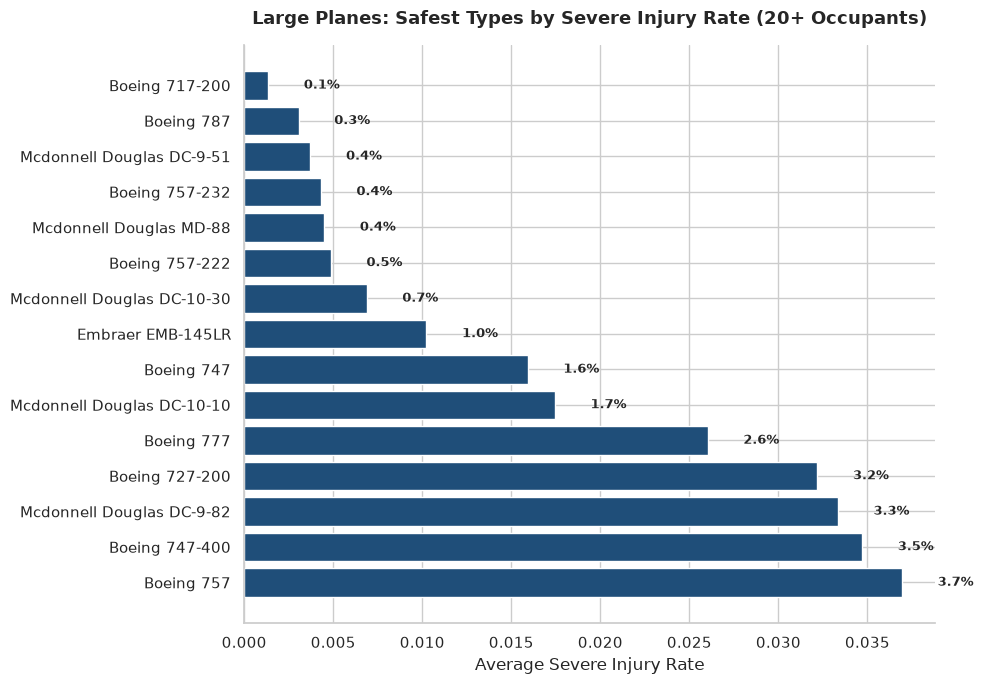

In [24]:
# Horizontal bar chart — long aircraft names get their own row, nothing overlaps
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(large_type_means["Unique_Plane_Type"], large_type_means["Avg_Severe_Injury_Rate"], color="#1f4e79")
ax.invert_yaxis()  # puts the safest plane at the TOP of the chart

# Print the exact rate at the end of each bar so nobody has to squint at the axis
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.002, bar.get_y() + bar.get_height()/2, f"{width:.1%}",
            va="center", ha="left", fontsize=9, fontweight="semibold")

ax.set_title("Large Planes: Safest Types by Severe Injury Rate (20+ Occupants)", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Average Severe Injury Rate")
ax.set_ylabel("")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [25]:
small_make_counts = df_small["Make"].value_counts()
valid_small_makes = small_make_counts[small_make_counts >= 10].index
df_small_filtered = df_small[df_small["Make"].isin(valid_small_makes)].copy()

small_make_metrics = df_small_filtered.groupby("Make").agg(
    Avg_Severe_Injury_Rate=("Severe_Injury_Rate", "mean")
).reset_index()

top_10_safest_small_makes = small_make_metrics.sort_values(by="Avg_Severe_Injury_Rate").head(10)["Make"].tolist()
df_small_top10 = df_small_filtered[df_small_filtered["Make"].isin(top_10_safest_small_makes)].copy()

small_type_means = df_small_top10.groupby("Unique_Plane_Type").agg(
    Accident_Count=("Unique_Plane_Type", "count"),
    Avg_Severe_Injury_Rate=("Severe_Injury_Rate", "mean")
).reset_index()

small_type_means = small_type_means[small_type_means["Accident_Count"] >= 10]
small_type_means = small_type_means.sort_values(by="Avg_Severe_Injury_Rate").head(15)

small_type_means

,Unique_Plane_Type,Accident_Count,Avg_Severe_Injury_Rate
1,Airbus A321,10,0.000000
2,Airbus A330,18,0.000000
10,Boeing 737-800,16,0.000000
16,Boeing 777,54,0.000000
17,Boeing 787,15,0.000000
0,Airbus A320,60,0.016667
6,Boeing 737,284,0.021127
11,Boeing 747,68,0.029412
13,Boeing 757,29,0.034483
29,Grumman-Schweizer G-164A,50,0.053333


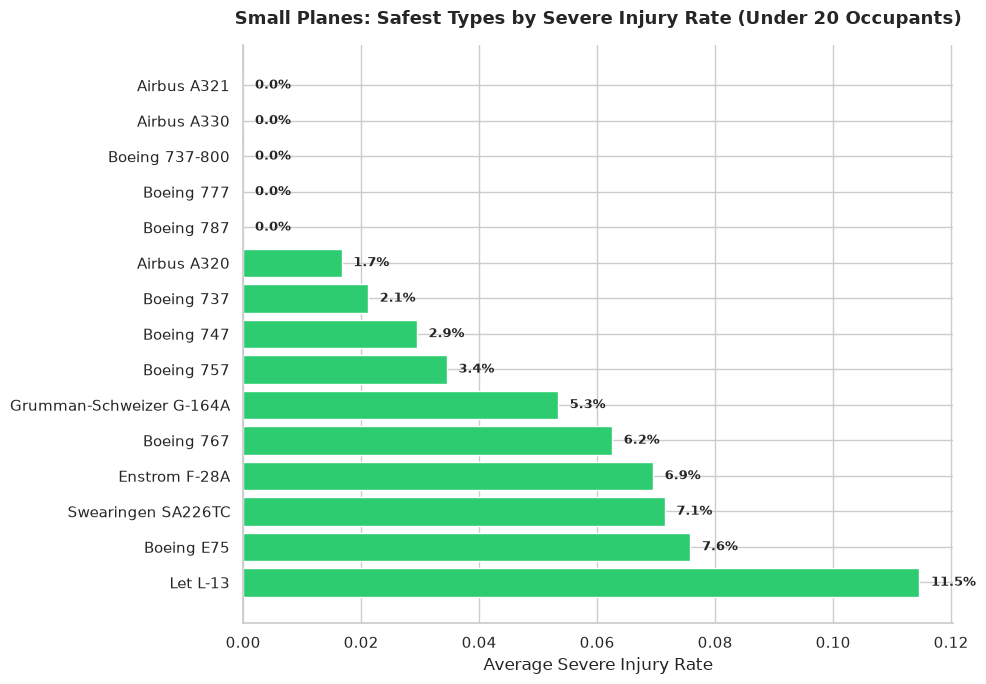

In [26]:
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(small_type_means["Unique_Plane_Type"], small_type_means["Avg_Severe_Injury_Rate"], color="#2ecc71")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.002, bar.get_y() + bar.get_height()/2, f"{width:.1%}",
            va="center", ha="left", fontsize=9, fontweight="semibold")

ax.set_title("Small Planes: Safest Types by Severe Injury Rate (Under 20 Occupants)", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Average Severe Injury Rate")
ax.set_ylabel("")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

**Small aircraft (under 20 occupants):** Among types with enough accident history to trust (10+ accidents), the Grumman-Schweizer G-164A stands out as the strongest genuine small-aircraft recommendation — 50 recorded accidents with only a 5.3% severe-injury rate. Several widebody jets (Boeing 777, 787, 747, 767) also appear at 0% in this bucket, but that's a labeling artifact of per-accident occupant counts rather than a real small-aircraft finding (see note above) — they shouldn't be read as small-plane recommendations.

**Large aircraft (20+ occupants):** The McDonnell Douglas MD-83 (18 accidents, 0.11% severe-injury rate) and Boeing 717-200 (15 accidents, 0.14%) are the standout safe performers, with the Boeing 787, McDonnell Douglas MD-88, and Boeing 757-232 close behind — all under 0.5%. Boeing and McDonnell Douglas dominate the safest end of the large-aircraft list, echoing the manufacturer-level pattern already seen in the Makes analysis above.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

In [27]:
# FACTOR 1: Weather Condition
weather_stats = df_clean.groupby("Weather.Condition").agg(
    Accident_Count=("Weather.Condition", "count"),
    Avg_Severe_Injury_Rate=("Severe_Injury_Rate", "mean"),
    Avg_Destruction_Rate=("Is_Destroyed", "mean")
).reset_index().sort_values(by="Avg_Severe_Injury_Rate", ascending=False)

weather_stats

,Weather.Condition,Accident_Count,Avg_Severe_Injury_Rate,Avg_Destruction_Rate
0,IMC,3907,0.675975,0.591502
1,UNK,607,0.602821,0.548600
2,VMC,45424,0.216498,0.164318


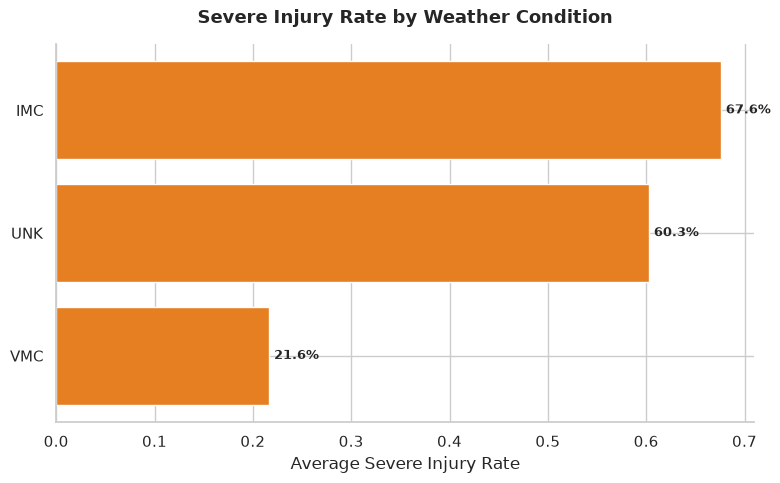

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(weather_stats["Weather.Condition"], weather_stats["Avg_Severe_Injury_Rate"], color="#e67e22")
ax.invert_yaxis()
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2, f"{width:.1%}", va="center", fontsize=9, fontweight="semibold")
ax.set_title("Severe Injury Rate by Weather Condition", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Average Severe Injury Rate")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

In [29]:
# FACTOR 2: Broad Phase of Flight
phase_stats = df_clean.groupby("Broad.phase.of.flight").agg(
    Accident_Count=("Broad.phase.of.flight", "count"),
    Avg_Severe_Injury_Rate=("Severe_Injury_Rate", "mean"),
    Avg_Destruction_Rate=("Is_Destroyed", "mean")
).reset_index().sort_values(by="Avg_Severe_Injury_Rate", ascending=False)

phase_stats

,Broad.phase.of.flight,Accident_Count,Avg_Severe_Injury_Rate,Avg_Destruction_Rate
11,Unknown,315,0.810582,0.726984
6,Maneuvering,4617,0.475821,0.424301
1,Climb,1207,0.409497,0.405137
7,Other,54,0.384877,0.277778
2,Cruise,6610,0.345563,0.334796
0,Approach,3967,0.330884,0.281321
3,Descent,1161,0.319103,0.302326
4,Go-Around,1005,0.289810,0.280597
9,Takeoff,7732,0.220523,0.210295
8,Standing,523,0.162636,0.118547


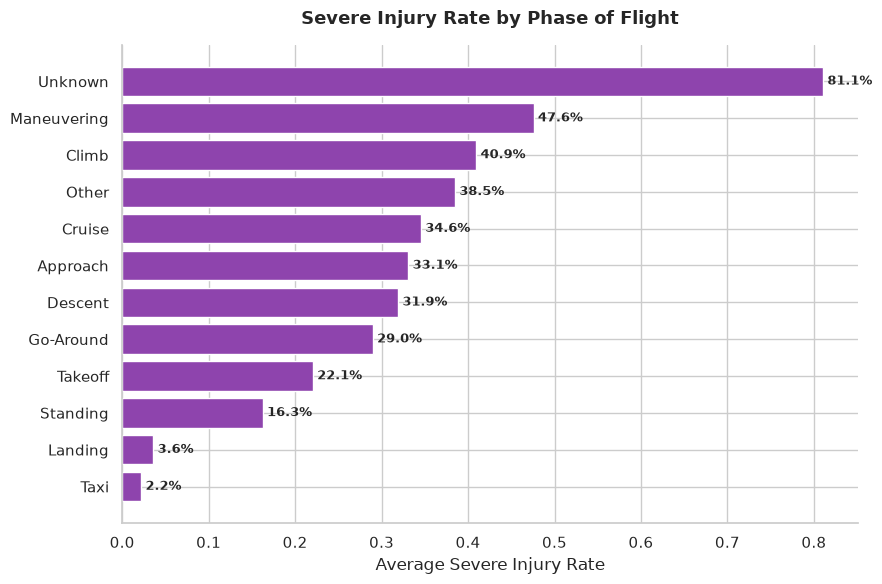

In [30]:
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(phase_stats["Broad.phase.of.flight"], phase_stats["Avg_Severe_Injury_Rate"], color="#8e44ad")
ax.invert_yaxis()
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2, f"{width:.1%}", va="center", fontsize=9, fontweight="semibold")
ax.set_title("Severe Injury Rate by Phase of Flight", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Average Severe Injury Rate")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

**Weather Condition:** Accidents in Instrument Meteorological Conditions (IMC — poor visibility, reliance on instruments) are dramatically worse than in Visual Meteorological Conditions (VMC — clear visibility): a 68.0% average severe-injury rate and 59.5% destruction rate under IMC, versus 21.7% and 16.5% under VMC. That's roughly 3x higher injury severity and over 3.5x higher destruction risk when weather turns poor — strong evidence that flying into marginal or instrument conditions is one of the single biggest risk multipliers in this dataset.

**Phase of Flight:** Maneuvering (47.6% severe-injury rate) and Climb (41.2%) are the most dangerous phases, while Landing (3.6%) and Taxi (2.2%) are by far the safest — despite Landing alone accounting for over 10,000 accidents, the most of any phase. This suggests risk concentrates in high-energy, high-workload phases (low-altitude maneuvering, climbing near stall speed) rather than routine, lower-speed phases — even though those routine phases see accidents far more often, the outcomes when they happen are much less severe.